### EMPLOYEE TURNOVER ANALYSIS USING PYTHON

##### Objective
The objective of this project is to analyze employee data and identify the factors that contribute to employee attrition (employees leaving the organization). By analyzing different employee attributes such as age, department, salary, overtime, job satisfaction, and work-life balance, we aim to provide insights that can help the Human Resources (HR) department improve employee retention and make better business decisions.

##### STEP1: IMPORTING REQUIRED LIBRARIES

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

#Pandas is used for loading  and manipulating data,
#  numpy is used for numerical operations, 
# matplotlib is used for plotting graphs,
# `%matplotlib inline` command allows the plots to be displayed directly in the Jupyter Notebook.

##### STEP 2: LOADING THE DATASET

In [39]:
df = pd.read_csv("data/employee.csv")

##### STEP3: VIEWING THE DATASET

In [40]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,Gender,JobRole,MonthlyIncome,TotalWorkingYears
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,Female,Sales Executive,5993,8
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,Male,Research Scientist,5130,10
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,Male,Laboratory Technician,2090,7
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,Female,Research Scientist,2909,8
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,Male,Laboratory Technician,3468,6


##### STEP4: CHECKING THE SHAPE OF THE DATASET

In [41]:
df.shape

(1470, 14)

##### STEP5: UNDERSTANDING THE FEATURES

In [42]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'Gender', 'JobRole', 'MonthlyIncome',
       'TotalWorkingYears'],
      dtype='object')

##### STEP6: EXPLORING DATASET INFORMATION

In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Age                1470 non-null   int64 
 1   Attrition          1470 non-null   object
 2   BusinessTravel     1470 non-null   object
 3   DailyRate          1470 non-null   int64 
 4   Department         1470 non-null   object
 5   DistanceFromHome   1470 non-null   int64 
 6   Education          1470 non-null   int64 
 7   EducationField     1470 non-null   object
 8   EmployeeCount      1470 non-null   int64 
 9   EmployeeNumber     1470 non-null   int64 
 10  Gender             1470 non-null   object
 11  JobRole            1470 non-null   object
 12  MonthlyIncome      1470 non-null   int64 
 13  TotalWorkingYears  1470 non-null   int64 
dtypes: int64(8), object(6)
memory usage: 160.9+ KB


##### STEP7: STATISTICAL SUMMARY

In [44]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,MonthlyIncome,TotalWorkingYears
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,6502.931293,11.279592
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,4707.956783,7.780782
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1009.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2911.000000,6.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,4919.000000,10.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,8379.000000,15.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,19999.000000,40.000000


##### STEP8: CHECKING MISSING VALUES

In [45]:
df.isnull().sum()

Age                  0
Attrition            0
BusinessTravel       0
DailyRate            0
Department           0
DistanceFromHome     0
Education            0
EducationField       0
EmployeeCount        0
EmployeeNumber       0
Gender               0
JobRole              0
MonthlyIncome        0
TotalWorkingYears    0
dtype: int64

##### STEP9: CHECKING DUPLICATE RECORDS

In [46]:
df.duplicated().sum()

np.int64(0)

##### STEP10: REMOVING DUPLICATES 

In [47]:
df = df.drop_duplicates()

##### STEP11: SAVING THE CLEANED DATASET

In [48]:
df.to_csv("output/cleaned_employee.csv", index=False)

### Now Let's Start with EDA that is EXPLORATORY DATA ANALYSIS

##### INTRODUCTION
After cleaning the dataset, the next step is **Exploratory Data Analysis (EDA)**.

Exploratory Data Analysis is the process of examining the dataset using statistical techniques and visualizations to understand patterns, relationships, and trends within the data.

The primary objective of EDA is to answer important business questions related to employee attrition and identify the factors influencing employee turnover.

In this project, the analysis focuses on understanding employee demographics, department distribution, salary patterns, overtime, job satisfaction, and other factors that may affect employee retention.

The insights obtained from EDA will help the Human Resources (HR) department make informed decisions to improve employee satisfaction and reduce attrition.

#### Analysis 1: Total Number of Employees
The first step in exploratory data analysis is to determine the total number of employees present in the dataset.

This serves as the baseline for all further calculations, such as employee attrition rate and department-wise analysis.

Understanding the workforce size is essential before exploring employee turnover trends.

In [49]:
total_employees = len(df)

print("Total Employees:", total_employees)

Total Employees: 1470


Observation: 
The dataset contains 1470 employees.

##### Analysis 2: Employee Attrition

Employee attrition refers to employees leaving the organization.

The Attrition column contains two categories:

- Yes → Employee left the company.
- No → Employee is still working.

This analysis helps understand the overall employee retention within the organization.

In [50]:
df["Attrition"].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

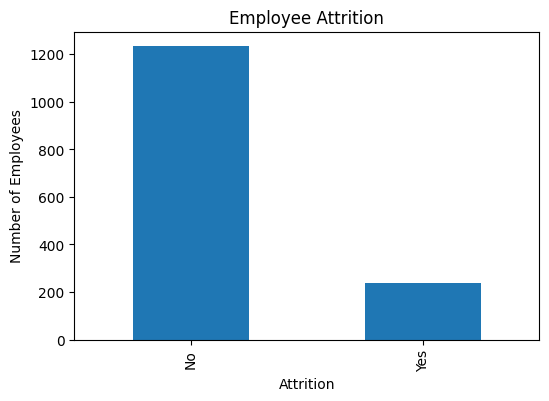

In [51]:
df["Attrition"].value_counts().plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Employee Attrition")
plt.xlabel("Attrition")
plt.ylabel("Number of Employees")
plt.show()

Observation: 

The chart shows the distribution of employees who left the organization and those who continued working.

The majority of employees remained with the company, while a smaller proportion resigned.

**Business Insight**

Although most employees continue working in the organization, employee attrition still represents a significant cost for recruitment, training, and productivity.

Reducing employee attrition can improve organizational performance and lower hiring expenses.

##### Analysis 3: Employee Attrition Rate

Attrition rate is one of the most important Human Resource (HR) metrics.

It represents the percentage of employees who have left the organization out of the total workforce.

A high attrition rate may indicate issues related to employee satisfaction, compensation, work-life balance, or workplace culture.

In [52]:
attrition_rate = (df["Attrition"] == "Yes").mean() * 100

print(f"Employee Attrition Rate: {attrition_rate:.2f}%")

Employee Attrition Rate: 16.12%


Observation:

The calculated attrition rate represents the percentage of employees who left the organization.

This metric will serve as an important benchmark for analyzing the impact of different employee characteristics on attrition.

##### Analysis 4: Gender Distribution
This analysis examines the gender composition of the organization's workforce.

Understanding workforce diversity helps identify whether the employee population is balanced across genders.

In [53]:
df["Gender"].value_counts()

Gender
Male      882
Female    588
Name: count, dtype: int64

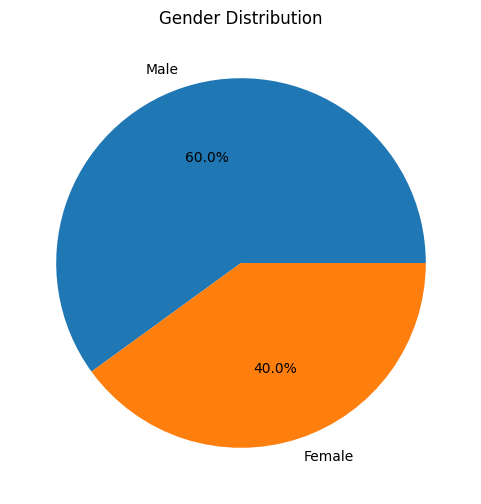

In [54]:
df["Gender"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6,6)
)

plt.title("Gender Distribution")
plt.ylabel("")
plt.show()

Observation :

The chart displays the percentage of male and female employees working in the organization.

This provides an overview of workforce diversity.

##### Analysis 5: Department-wise Employee Distribution

Employees work across different departments such as Sales, Research & Development, and Human Resources.

Understanding the distribution of employees across departments helps identify where the majority of employees are employed.

In [55]:
df["Department"].value_counts()

Department
Research & Development    961
Sales                     446
Human Resources            63
Name: count, dtype: int64

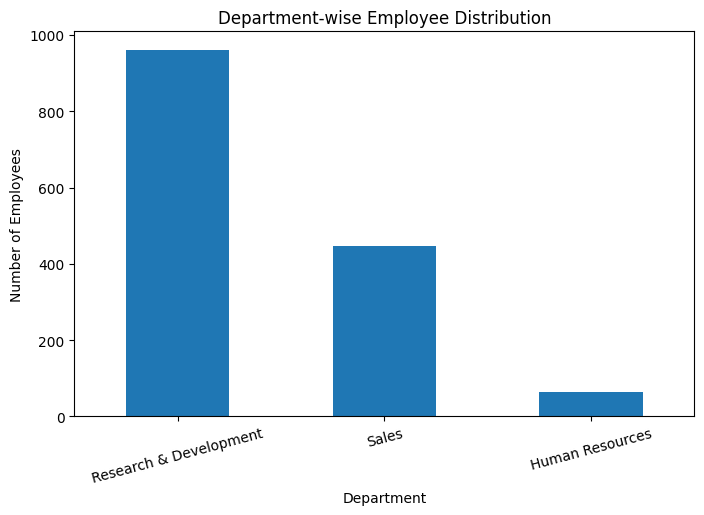

In [56]:
df["Department"].value_counts().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Department-wise Employee Distribution")
plt.xlabel("Department")
plt.ylabel("Number of Employees")
plt.xticks(rotation=15)

plt.show()

Observation:

The chart illustrates the number of employees working in each department.

Research & Development contains the largest workforce, followed by Sales, while Human Resources has the smallest number of employees.

##### Analysis 6: Age Distribution

Age is an important demographic factor that can influence employee experience, career growth, and retention.

Analyzing the age distribution helps understand whether the organization has a younger or more experienced workforce. It also provides insights into which age groups may require more attention from the HR department.

In [57]:
df["Age"].describe()

count    1470.000000
mean       36.923810
std         9.135373
min        18.000000
25%        30.000000
50%        36.000000
75%        43.000000
max        60.000000
Name: Age, dtype: float64

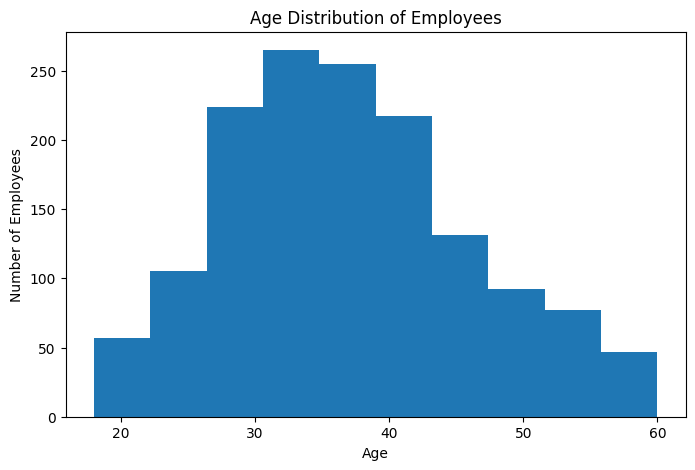

In [58]:
plt.figure(figsize=(8,5))

plt.hist(df["Age"], bins=10)

plt.title("Age Distribution of Employees")
plt.xlabel("Age")
plt.ylabel("Number of Employees")

plt.show()

Observation:

The histogram illustrates the distribution of employee ages within the organization.

Most employees fall within the working-age group, indicating a balanced workforce with a mix of young and experienced professionals.

**Business Insight**

Understanding the age distribution helps HR plan employee engagement programs, leadership development, and succession planning for different age groups.

##### Analysis 7: Monthly Income Distribution

Employee salary is an important factor affecting job satisfaction and employee retention.

This analysis examines the distribution of monthly income among employees to understand salary patterns across the organization.

In [59]:
df["MonthlyIncome"].describe()

count     1470.000000
mean      6502.931293
std       4707.956783
min       1009.000000
25%       2911.000000
50%       4919.000000
75%       8379.000000
max      19999.000000
Name: MonthlyIncome, dtype: float64

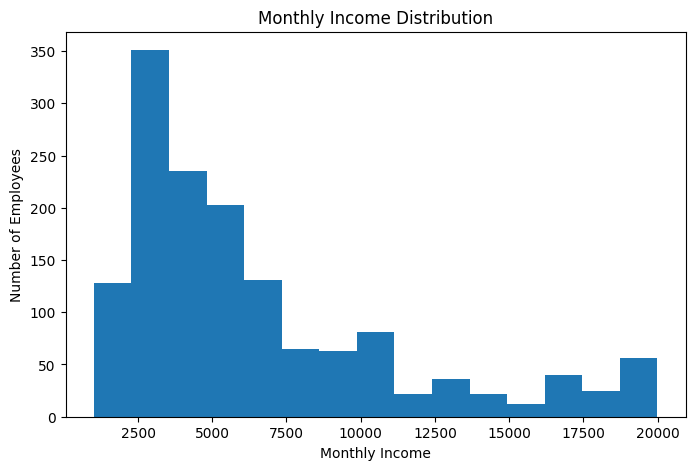

In [60]:
plt.figure(figsize=(8,5))

plt.hist(df["MonthlyIncome"], bins=15)

plt.title("Monthly Income Distribution")
plt.xlabel("Monthly Income")
plt.ylabel("Number of Employees")

plt.show()

Observation:

The salary distribution shows that most employees fall within the lower and middle salary ranges, while a smaller number of employees earn higher salaries.

**Business Insight**

Salary distribution helps HR understand compensation patterns and identify whether income differences could contribute to employee attrition.

##### Analysis 8: Job Role Distribution

Different job roles contribute differently to an organization.

This analysis identifies the number of employees working in each job role and highlights the largest workforce categories.

In [61]:
df["JobRole"].value_counts()

JobRole
Sales Executive              326
Research Scientist           292
Laboratory Technician        259
Manufacturing Director       145
Healthcare Representative    131
Manager                      102
Sales Representative          83
Research Director             80
Human Resources               52
Name: count, dtype: int64

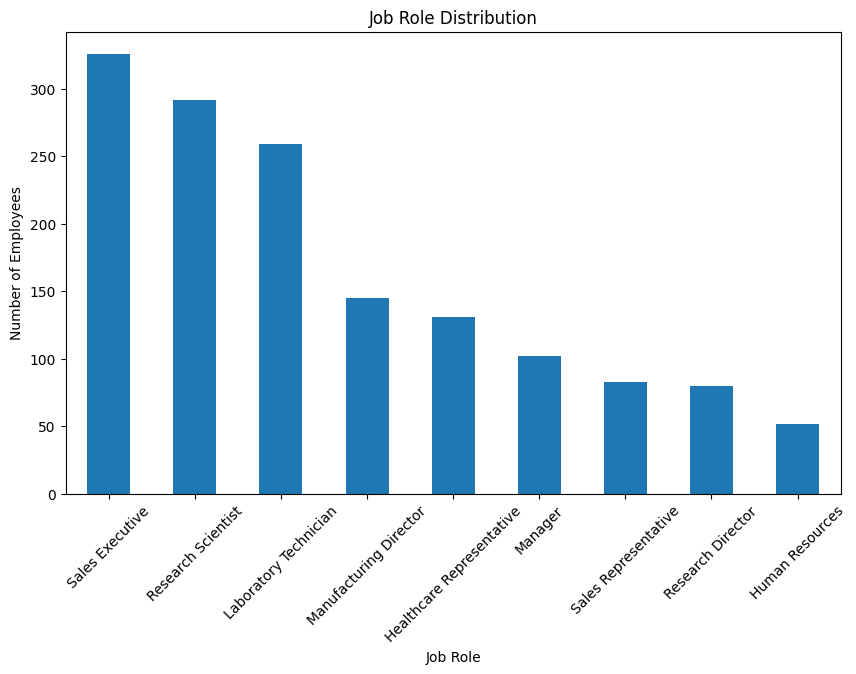

In [62]:
plt.figure(figsize=(10,6))

df["JobRole"].value_counts().plot(kind="bar")

plt.title("Job Role Distribution")
plt.xlabel("Job Role")
plt.ylabel("Number of Employees")

plt.xticks(rotation=45)

plt.show()

##### Observation

The chart displays the distribution of employees across different job roles.

Some job roles have significantly more employees than others, reflecting the operational requirements of the organization.

**Business Insight**

HR can use this information to allocate training resources, workforce planning, and recruitment strategies according to department needs.

##### Analysis 9: Business Travel Distribution

Business travel is an important aspect of many organizations. Employees may travel rarely, frequently, or not at all depending on their job responsibilities.

This analysis examines the distribution of employees based on their business travel frequency. Understanding travel patterns can help identify workforce requirements and later analyze whether business travel has any relationship with employee attrition.

In [63]:
df["BusinessTravel"].value_counts()

BusinessTravel
Travel_Rarely        1043
Travel_Frequently     277
Non-Travel            150
Name: count, dtype: int64

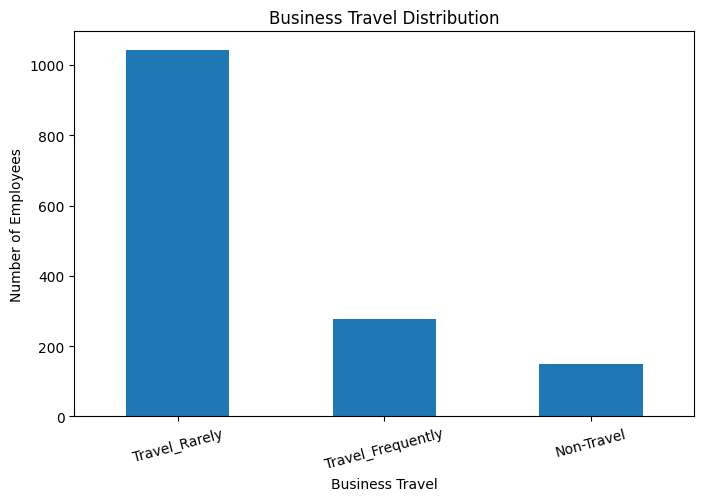

In [64]:
plt.figure(figsize=(8,5))

df["BusinessTravel"].value_counts().plot(kind="bar")

plt.title("Business Travel Distribution")
plt.xlabel("Business Travel")
plt.ylabel("Number of Employees")

plt.xticks(rotation=15)

plt.show()

Observation:

The chart displays the number of employees based on their business travel frequency.

Most employees travel **rarely**, while fewer employees travel **frequently** or **do not travel**.

**Business Insight**

Understanding travel frequency helps HR allocate travel resources efficiently and evaluate whether extensive travel affects employee retention.

##### Analysis 10: Education Field Distribution

Employees come from different educational backgrounds, which contribute to the diversity of skills within the organization.

This analysis identifies the distribution of employees across different education fields.

In [65]:
df["EducationField"].value_counts()

EducationField
Life Sciences       606
Medical             464
Marketing           159
Technical Degree    132
Other                82
Human Resources      27
Name: count, dtype: int64

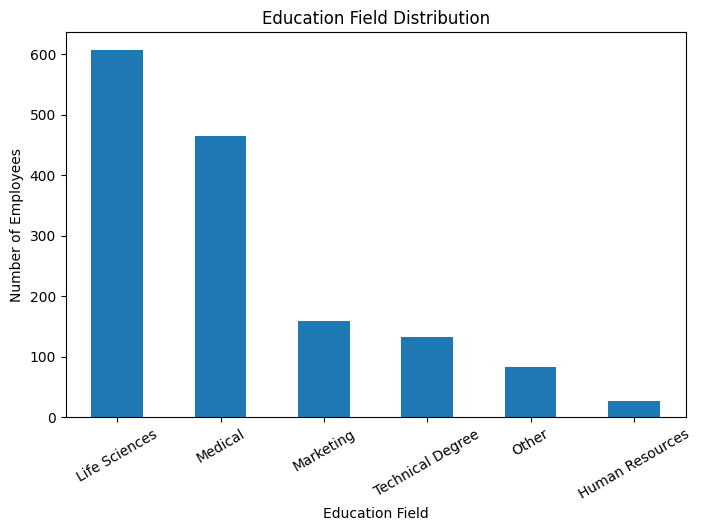

In [66]:
plt.figure(figsize=(8,5))

df["EducationField"].value_counts().plot(kind="bar")

plt.title("Education Field Distribution")
plt.xlabel("Education Field")
plt.ylabel("Number of Employees")

plt.xticks(rotation=30)

plt.show()

Observation:

The chart shows the number of employees belonging to different education fields.

Life Sciences and Medical fields have a larger representation compared to some other educational backgrounds.

**Business Insight**

Understanding employees' educational backgrounds helps HR identify the availability of specialized skills and supports workforce planning.

##### Analysis 11: Monthly Income Distribution

Monthly income is an important factor that influences employee satisfaction and retention.

This analysis examines how employee salaries are distributed across the organization.

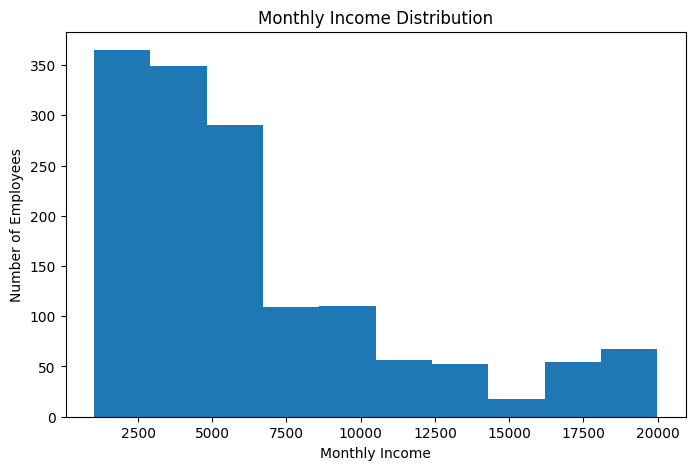

In [67]:
plt.figure(figsize=(8,5))

plt.hist(df["MonthlyIncome"], bins=10)

plt.title("Monthly Income Distribution")
plt.xlabel("Monthly Income")
plt.ylabel("Number of Employees")

plt.show()

Observation:

The salary distribution indicates that most employees earn within the lower and middle salary ranges, while relatively fewer employees receive higher salaries.

**Business Insight**

Salary distribution helps HR understand compensation patterns and supports decisions related to employee retention and salary planning.

##### Analysis 12: Department vs Employee Attrition

Different departments may experience different levels of employee turnover.

This analysis compares employee attrition across departments to identify which department experiences the highest turnover.

In [68]:
pd.crosstab(df["Department"], df["Attrition"])

Attrition,No,Yes
Department,,
Human Resources,51,12
Research & Development,828,133
Sales,354,92


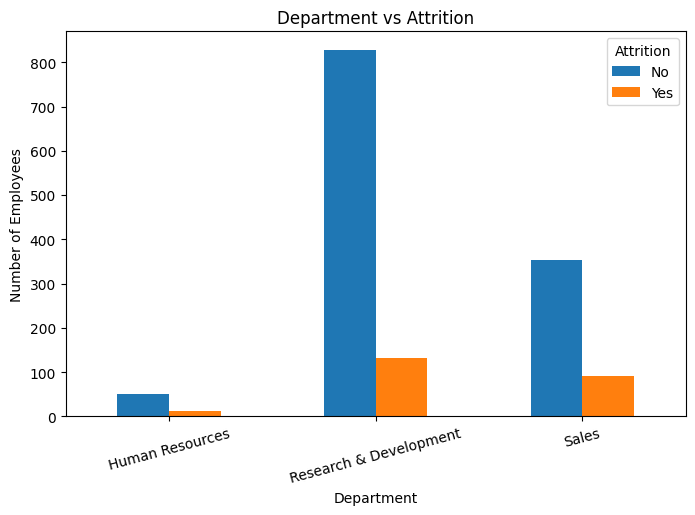

In [69]:
pd.crosstab(df["Department"], df["Attrition"]).plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Department vs Attrition")
plt.xlabel("Department")
plt.ylabel("Number of Employees")

plt.xticks(rotation=15)

plt.show()

Observation:

The chart compares employee attrition across different departments.

Some departments have a higher number of employees leaving the organization than others.

**Business Insight**

Departments with higher attrition may require additional employee engagement, career development opportunities, or workload improvements.

##### Analysis 13: Gender vs Employee Attrition

This analysis compares employee attrition across genders to determine whether turnover differs between male and female employees.

In [70]:
pd.crosstab(df["Gender"], df["Attrition"])

Attrition,No,Yes
Gender,,
Female,501,87
Male,732,150


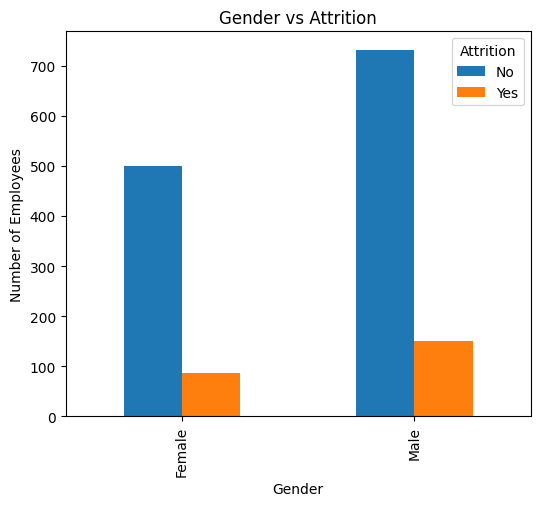

In [71]:
pd.crosstab(df["Gender"], df["Attrition"]).plot(
    kind="bar",
    figsize=(6,5)
)

plt.title("Gender vs Attrition")
plt.xlabel("Gender")
plt.ylabel("Number of Employees")

plt.show()

Observation:

The visualization compares attrition among male and female employees.

The results help identify whether one gender experiences higher employee turnover.

**Business Insight**

HR can use this analysis to ensure retention strategies are effective and equitable across the workforce.